Day9 Understanding Second order derivative

In first order derivative we understood how something changes. In second order is how fast does this change occur, in a way if first order is velocity then this is acceleration

This is computed with the help of Laplace filter

4 neighbour 
[
    [0  1  0]
    [1 -4  1]
    [0  1  0]
]


8 neighbour 
[
    [1  1  1]
    [1 -8  1]
    [1  1  1]
]

Second order derivative will detect an edge when there is change in sign or zero crossing

In [2]:
import cv2
import matplotlib.pyplot as plt
import numpy as np


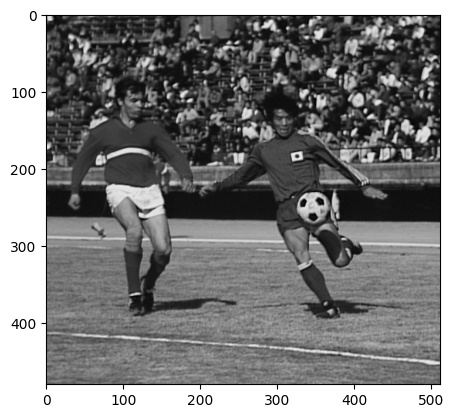

In [3]:
img=cv2.imread("soccer.bmp",0)
plt.imshow(img,vmax=255,vmin=0,cmap='gray')
plt.show()


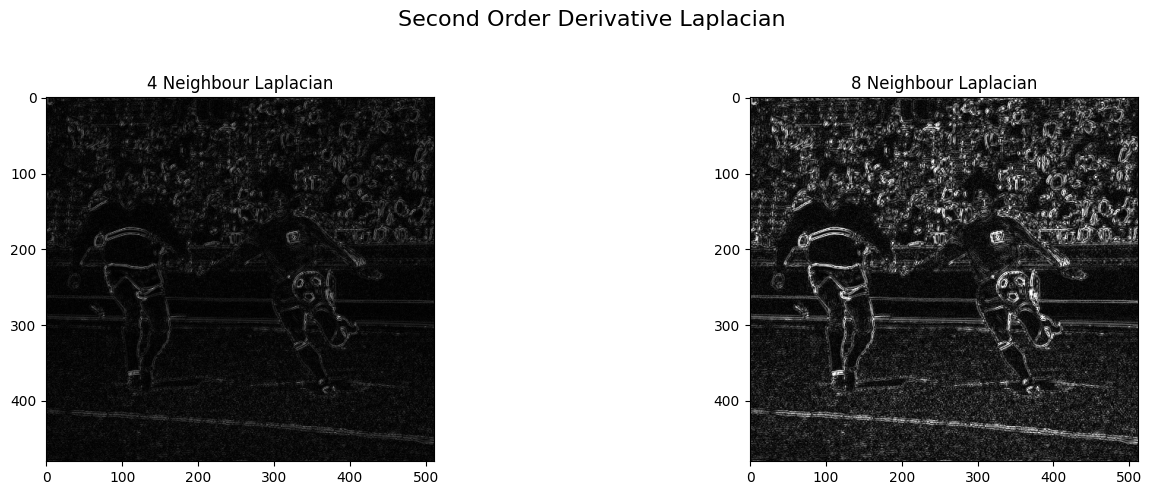

In [4]:
Lap4Nfilter=np.array([[0,1,0],[1,-4,1],[0,1,0]])
Lap4N=cv2.filter2D(img,cv2.CV_32F,Lap4Nfilter)
Lap8Nfilter=np.array([[1,1,1],[1,-8,1],[1,1,1]])
Lap8N=cv2.filter2D(img,cv2.CV_32F,Lap8Nfilter)

absLap4N=cv2.convertScaleAbs(Lap4N)
absLap8N=cv2.convertScaleAbs(Lap8N)

plt.figure(figsize=(15,5))
plt.suptitle("Second Order Derivative Laplacian",fontsize=16)

plt.subplot(1,2,1)
plt.imshow(absLap4N,cmap="gray",vmin=0,vmax=255)
plt.title("4 Neighbour Laplacian")

plt.subplot(1,2,2)
plt.imshow(absLap8N,cmap="gray",vmin=0,vmax=255)
plt.title("8 Neighbour Laplacian")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

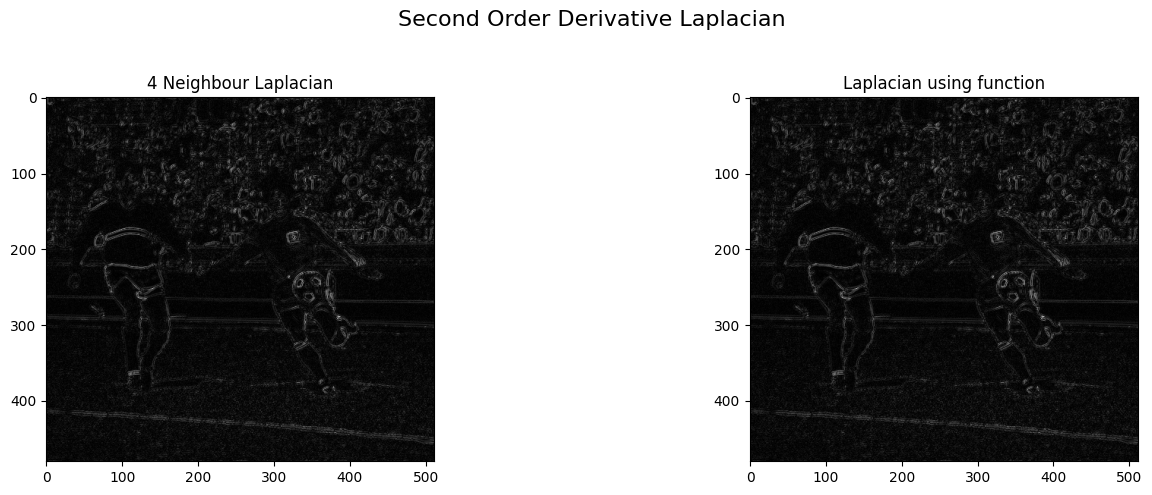

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [7]:
Lap=cv2.Laplacian(img,cv2.CV_32F)
absLap=cv2.convertScaleAbs(Lap)
plt.figure(figsize=(15,5))
plt.suptitle("Second Order Derivative Laplacian",fontsize=16)

plt.subplot(1,2,1)
plt.imshow(absLap4N,cmap="gray",vmin=0,vmax=255)
plt.title("4 Neighbour Laplacian")

plt.subplot(1,2,2)
plt.imshow(absLap,cmap="gray",vmin=0,vmax=255)
plt.title("Laplacian using function")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
print(Lap-Lap4N)

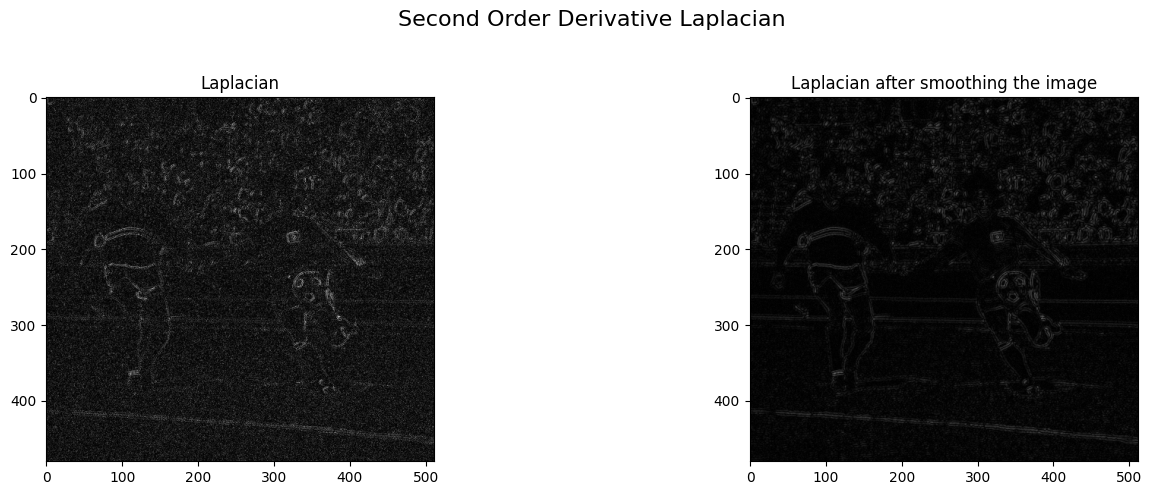

In [ ]:
noise=np.random.normal(0,5,img.shape)
noisyimg=np.clip(img+noise,0,255)
noisyimg=noisyimg.astype(np.uint8)

noisyLap=cv2.Laplacian(noisyimg,cv2.CV_32F)
absnoisyLap=cv2.convertScaleAbs(noisyLap)

smoothImg=cv2.GaussianBlur(noisyimg,(3,3),0)
smoothLap=cv2.Laplacian(smoothImg,cv2.CV_32F)
abssmoothLap=cv2.convertScaleAbs(smoothLap)
plt.figure(figsize=(15,5))
plt.suptitle("Second Order Derivative Laplacian",fontsize=16)

plt.subplot(1,2,1)
plt.imshow(absnoisyLap,cmap="gray",vmin=0,vmax=255)
plt.title("Laplacian")

plt.subplot(1,2,2)
plt.imshow(abssmoothLap,cmap="gray",vmin=0,vmax=255)
plt.title("Laplacian after filtering Noise(LoG)")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

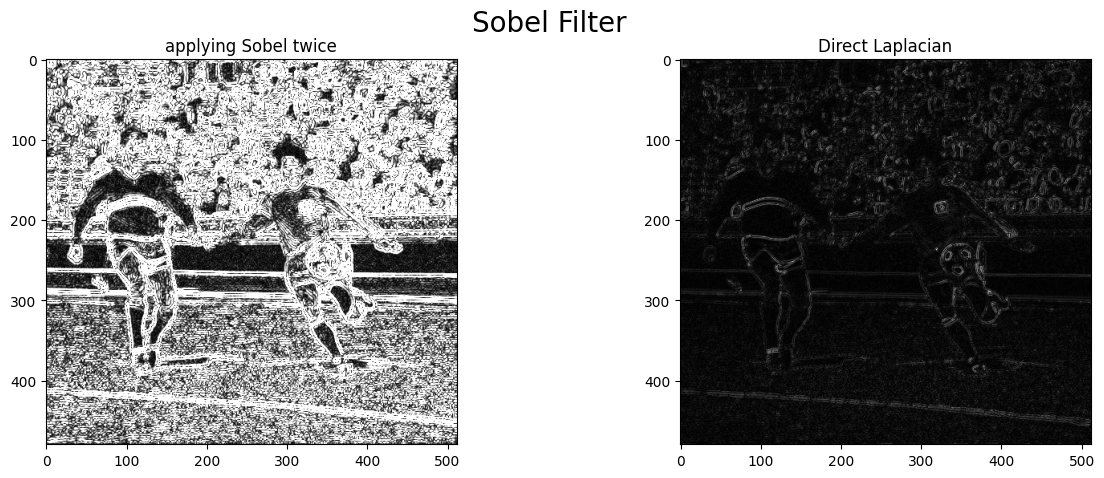

In [ ]:
SobelX=np.array([[-1,0,1],[-1,0,1],[-1,0,1]])
SobelY=np.transpose(SobelX)
Sx=cv2.filter2D(img,cv2.CV_32F,SobelX)
S2x=cv2.Sobel(img,cv2.CV_32F,2,0,ksize=3)
S2y=cv2.Sobel(img,cv2.CV_32F,0,2,ksize=3)

lap=S2x+S2y
abslap=cv2.convertScaleAbs(lap)

plt.figure(figsize=(15,5))

plt.subplot(1,2,1)
plt.imshow(abslap,cmap="gray",)
plt.title("applying Sobel twice")

plt.subplot(1,2,2)
plt.imshow(absLap,cmap="gray",vmin=0,vmax=255)
plt.title("Direct Laplacian")
plt.suptitle("Sobel Filter",fontsize=20)
plt.show()